# LeWM (LeWorldModel) — Visual Experiments

> **Goal:** See why a single isotropic-Gaussian regularizer stabilizes a JEPA world model, and how the learned latent encodes physical structure.

## What we'll explore

| # | Experiment | Question answered |
|---|---|---|
| 1 | **JEPA collapse** | Without anti-collapse, does next-embedding prediction degenerate to a constant? |
| 2 | **Gaussian regularizer** | Does one isotropy regularizer prevent collapse, replacing EMA/contrastive? |
| 3 | **Physical structure** | Can we probe the learned latent for the true physical state? |
| 4 | **Surprise detection** | Does prediction error flag physically implausible transitions? |

---
**Linked theory:** [research/08-lewm.md](../research/08-lewm.md)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(0)
np.random.seed(42)
plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.35,
})


def make_data(n=4000):
    """A point rotating on a circle; action = angular step. Obs has distractor dims."""
    theta = np.random.uniform(0, 2 * np.pi, n)
    a = np.random.uniform(-0.4, 0.4, n)
    theta_next = theta + a
    def obs(th):
        return np.stack([np.cos(th), np.sin(th),
                         0.5 * np.random.randn(len(th)), 0.5 * np.random.randn(len(th))], 1)
    return (torch.tensor(obs(theta), dtype=torch.float32),
            torch.tensor(a[:, None], dtype=torch.float32),
            torch.tensor(obs(theta_next), dtype=torch.float32),
            theta)


OBS, ACT, OBS_NEXT, THETA = make_data()
print('data:', OBS.shape, '(2 informative + 2 distractor dims)')

data: torch.Size([4000, 4]) (2 informative + 2 distractor dims)


---
## Experiment 1: JEPA collapse

**Question:** A JEPA predicts the embedding of the next observation. If we train this end-to-end with *only* the prediction loss and a shared encoder, what stops the trivial solution where every embedding is the same constant (zero loss)?

We train an encoder + action-conditioned predictor with prediction loss alone and track the embedding's standard deviation — collapse shows up as the std going to zero.

In [2]:
torch.manual_seed(1)
D = 8


def make_models():
    enc = nn.Sequential(nn.Linear(4, 64), nn.SiLU(), nn.Linear(64, D))
    pred = nn.Sequential(nn.Linear(D + 1, 64), nn.SiLU(), nn.Linear(64, D))
    return enc, pred


def gaussian_reg(z):
    # push embeddings toward isotropic Gaussian: mean 0, unit variance, decorrelated
    mu = z.mean(0)
    std = z.std(0)
    zc = z - mu
    cov = (zc.T @ zc) / (z.shape[0] - 1)
    off = cov - torch.diag(torch.diag(cov))
    return (mu ** 2).mean() + ((std - 1) ** 2).mean() + (off ** 2).mean()


def train(lam, steps=1500):
    enc, pred = make_models()
    opt = torch.optim.Adam(list(enc.parameters()) + list(pred.parameters()), lr=2e-3)
    std_hist = []
    for _ in range(steps):
        idx = torch.randint(0, len(OBS), (256,))
        z = enc(OBS[idx]); z_next = enc(OBS_NEXT[idx])
        pred_loss = ((pred(torch.cat([z, ACT[idx]], 1)) - z_next) ** 2).mean()
        loss = pred_loss + lam * gaussian_reg(z)
        opt.zero_grad(); loss.backward(); opt.step()
        std_hist.append(enc(OBS[:1000]).std().item())
    return enc, pred, np.array(std_hist)


enc_collapse, _, std_collapse = train(lam=0.0)
print(f'no regularizer -> final embedding std: {std_collapse[-1]:.4f}')

no regularizer -> final embedding std: 0.0562


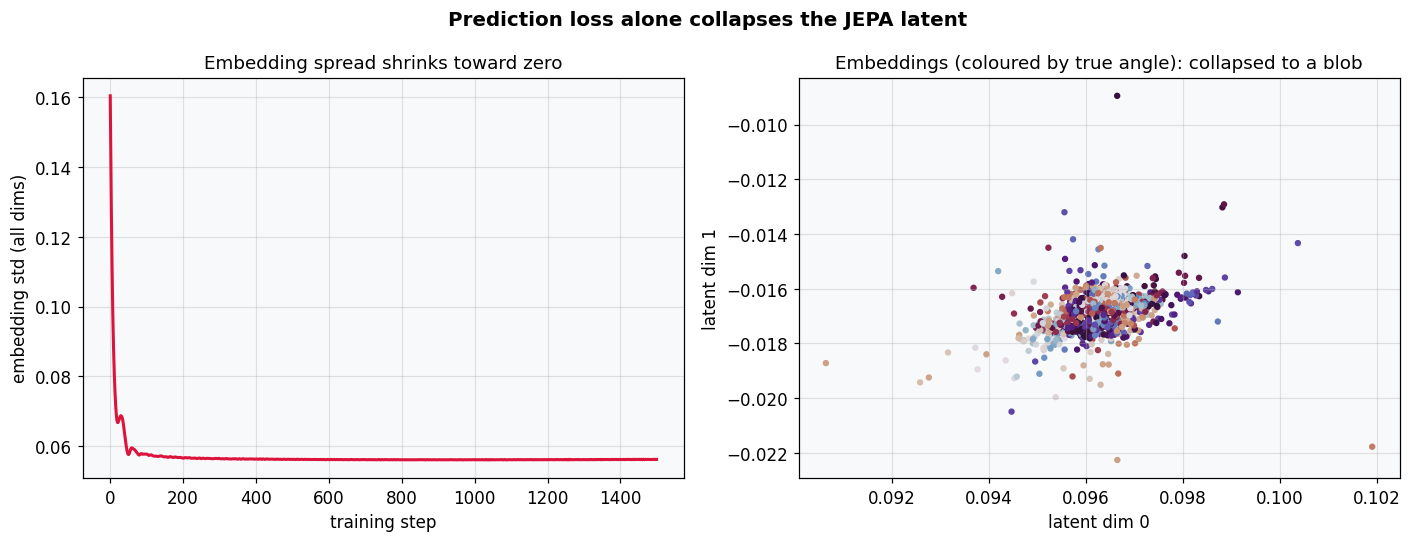

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Prediction loss alone collapses the JEPA latent', fontsize=13, fontweight='bold')

axes[0].plot(std_collapse, color='crimson', lw=2)
axes[0].set_xlabel('training step'); axes[0].set_ylabel('embedding std (all dims)')
axes[0].set_title('Embedding spread shrinks toward zero')

with torch.no_grad():
    zc = enc_collapse(OBS[:1500]).numpy()
axes[1].scatter(zc[:, 0], zc[:, 1], c=THETA[:1500], cmap='twilight', s=10)
axes[1].set_xlabel('latent dim 0'); axes[1].set_ylabel('latent dim 1')
axes[1].set_title('Embeddings (coloured by true angle): collapsed to a blob')

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** The embedding std falls toward zero over training (left), and the embeddings pile into a tiny blob with the angle colours all mixed (right) — the latent has lost the information it should carry.
2. **Why it looks this way:** When the encoder is free and there is no anti-collapse term, the easiest way to make next-embedding prediction error zero is to map *every* observation to the same constant. Loss is minimized, but the representation is useless.
3. **Key takeaway:** Representation collapse is the central danger of JEPA — predicting in embedding space invites the degenerate constant solution unless something prevents it.

---
## Experiment 2: Gaussian regularizer

**Question:** Earlier JEPAs needed EMA targets, stop-gradient tricks, or contrastive negatives to avoid collapse. Can a single isotropic-Gaussian regularizer do it instead?

We add LeWM's regularizer — pushing embeddings toward mean 0, unit variance, decorrelated dimensions — and compare the embedding spread against the collapsed run.

In [4]:
enc_lewm, pred_lewm, std_lewm = train(lam=1.0)
with torch.no_grad():
    z_lewm = enc_lewm(OBS[:1500]).numpy()
print(f'with regularizer -> final embedding std: {std_lewm[-1]:.3f} (collapsed run: {std_collapse[-1]:.4f})')

with regularizer -> final embedding std: 0.773 (collapsed run: 0.0562)


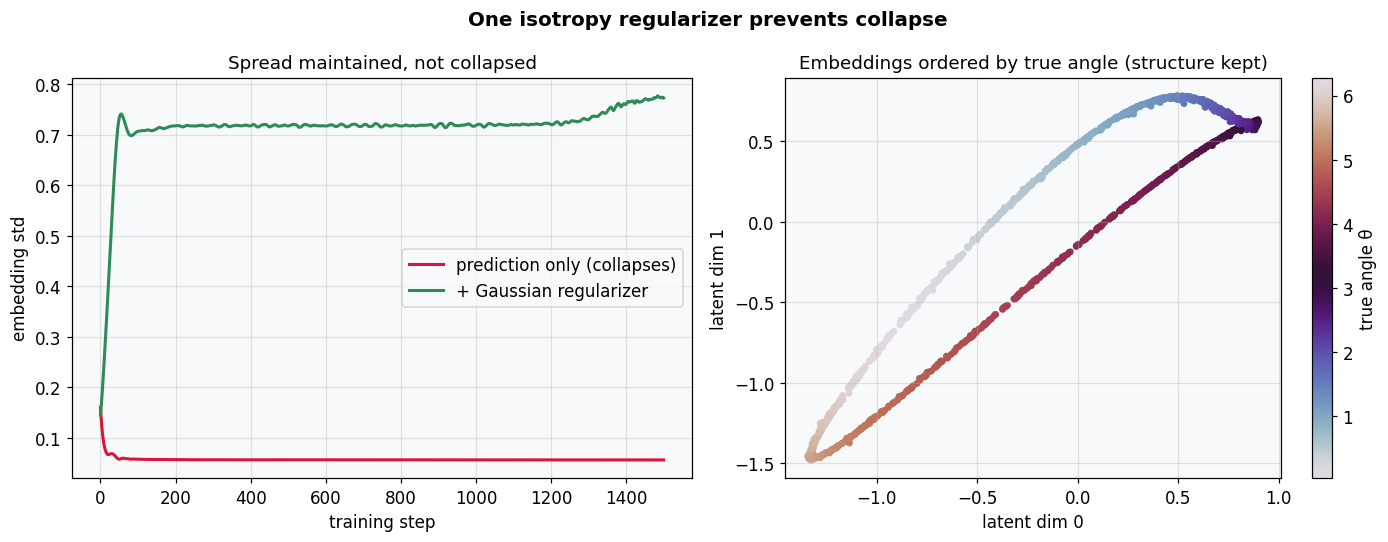

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('One isotropy regularizer prevents collapse', fontsize=13, fontweight='bold')

axes[0].plot(std_collapse, color='crimson', lw=2, label='prediction only (collapses)')
axes[0].plot(std_lewm, color='seagreen', lw=2, label='+ Gaussian regularizer')
axes[0].set_xlabel('training step'); axes[0].set_ylabel('embedding std')
axes[0].set_title('Spread maintained, not collapsed')
axes[0].legend()

sc = axes[1].scatter(z_lewm[:, 0], z_lewm[:, 1], c=THETA[:1500], cmap='twilight', s=12)
axes[1].set_xlabel('latent dim 0'); axes[1].set_ylabel('latent dim 1')
axes[1].set_title('Embeddings ordered by true angle (structure kept)')
fig.colorbar(sc, ax=axes[1], label='true angle θ')

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** With the regularizer, the embedding std stays around 1 instead of collapsing (left), and the embeddings spread out and vary smoothly with the true angle (colour gradient, right) instead of piling into a blob.
2. **Why it looks this way:** Forcing the embedding distribution toward an isotropic Gaussian (mean 0, unit variance, decorrelated) makes the constant solution impossible — a constant has zero variance, which the regularizer punishes. The encoder must keep information to satisfy it.
3. **Key takeaway:** A single isotropy regularizer replaces the whole bag of anti-collapse tricks — LeWM's core simplification, cutting six loss hyperparameters to one.

---
## Experiment 3: Physical structure

**Question:** LeWM reports that probing its latent recovers physical quantities. Does our non-collapsed latent encode the true physical state (the angle), even though it never reconstructed pixels?

We linearly probe the learned embedding for $\cos\theta$ and $\sin\theta$ (the true state) and measure the fit.

In [6]:
with torch.no_grad():
    Z = enc_lewm(OBS).numpy()
targets = np.stack([np.cos(THETA), np.sin(THETA)], 1)
# linear probe (least squares) from latent -> (cos, sin)
Zb = np.concatenate([Z, np.ones((len(Z), 1))], 1)
W, *_ = np.linalg.lstsq(Zb[:3000], targets[:3000], rcond=None)
pred_state = Zb[3000:] @ W
true_state = targets[3000:]
r2 = 1 - ((true_state - pred_state) ** 2).sum() / ((true_state - true_state.mean(0)) ** 2).sum()
print(f'linear-probe R^2 for (cosθ, sinθ) from latent: {r2:.3f}')

linear-probe R^2 for (cosθ, sinθ) from latent: 1.000


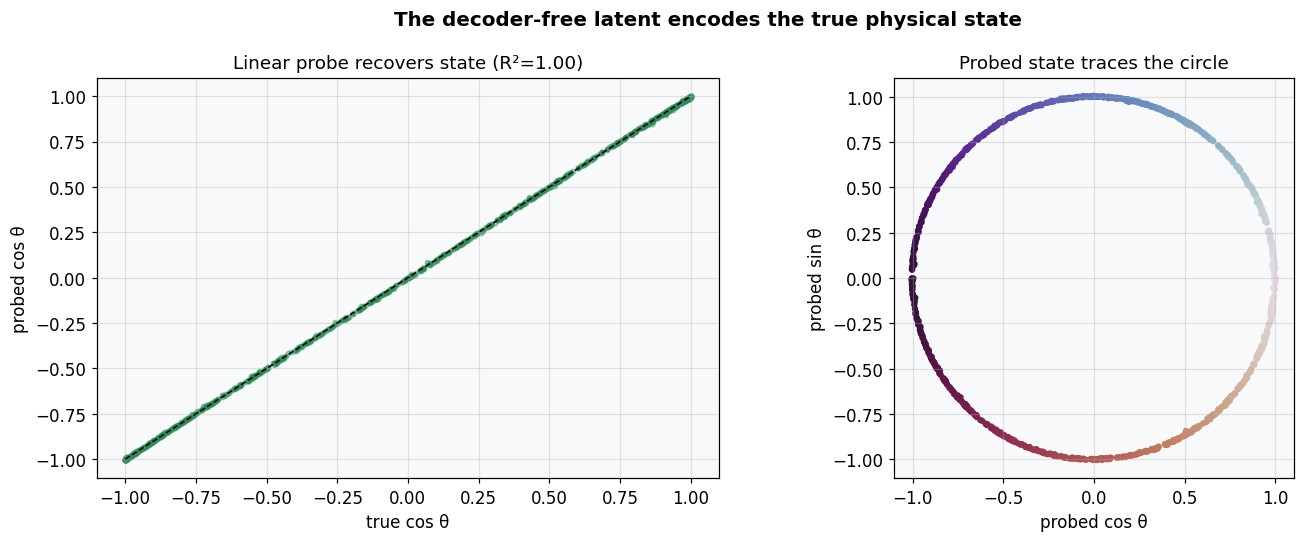

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('The decoder-free latent encodes the true physical state', fontsize=13, fontweight='bold')

axes[0].scatter(true_state[:, 0], pred_state[:, 0], s=8, alpha=0.4, color='seagreen')
axes[0].plot([-1, 1], [-1, 1], 'k--', lw=1)
axes[0].set_xlabel('true cos θ'); axes[0].set_ylabel('probed cos θ')
axes[0].set_title(f'Linear probe recovers state (R²={r2:.2f})')

axes[1].scatter(pred_state[:, 0], pred_state[:, 1], c=THETA[3000:], cmap='twilight', s=10)
axes[1].set_xlabel('probed cos θ'); axes[1].set_ylabel('probed sin θ')
axes[1].set_title('Probed state traces the circle')
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** A linear probe predicts the true $\cos\theta$ closely (points hug the diagonal, high $R^2$), and the probed $(\cos\theta,\sin\theta)$ trace out the original circle ordered by angle.
2. **Why it looks this way:** To predict the next embedding under the action (a rotation), the encoder must represent the angle — so the physical state becomes linearly decodable from the latent, even though the model never reconstructed the observation and ignored the distractor dims.
3. **Key takeaway:** Predicting in latent forces the encoder to capture the genuine generative factors — the basis of LeWM's claim that its latent holds probeable physical structure.

---
## Experiment 4: Surprise detection

**Question:** LeWM uses prediction error as a 'surprise' signal to flag physically implausible events. Does the next-embedding error separate normal transitions from impossible ones?

We compute the predictor's error on normal transitions versus transitions where the point teleports (an action-inconsistent, physically implausible jump).

In [8]:
torch.manual_seed(4)
obs_t, act_t, obs_next, th = make_data(1500)
# implausible: next observation is a random teleport, inconsistent with the action
perm = torch.randperm(len(obs_next))
obs_next_bad = obs_next[perm]


@torch.no_grad()
def surprise(o_t, a, o_next):
    z = enc_lewm(o_t); z_pred = pred_lewm(torch.cat([z, a], 1)); z_next = enc_lewm(o_next)
    return ((z_pred - z_next) ** 2).mean(1).numpy()


s_normal = surprise(obs_t, act_t, obs_next)
s_bad = surprise(obs_t, act_t, obs_next_bad)
print(f'mean surprise  normal: {s_normal.mean():.3f}   implausible: {s_bad.mean():.3f}')

mean surprise  normal: 0.010   implausible: 1.177


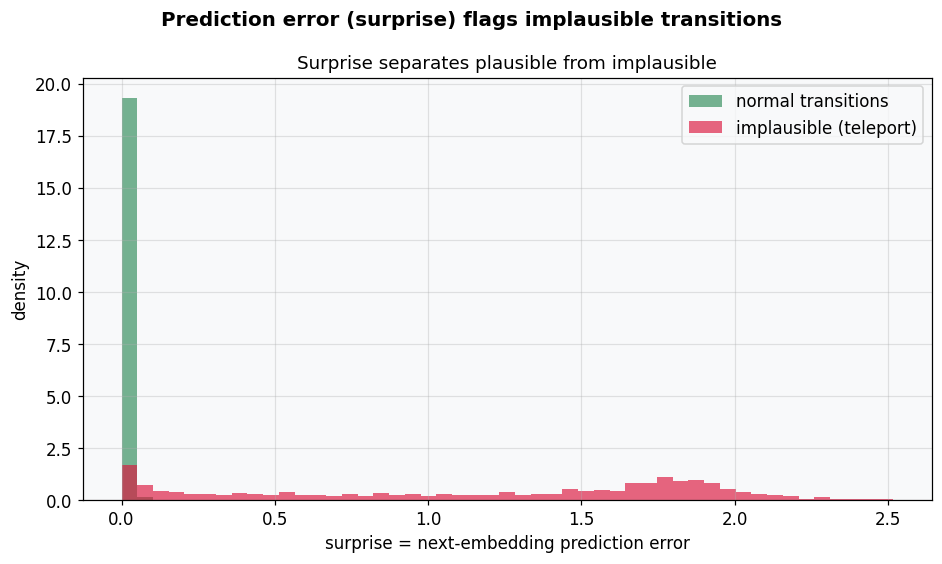

In [9]:
fig, ax = plt.subplots(figsize=(8.7, 5.2))
fig.suptitle('Prediction error (surprise) flags implausible transitions', fontsize=13, fontweight='bold')

bins = np.linspace(0, max(s_bad.max(), s_normal.max()), 50)
ax.hist(s_normal, bins=bins, alpha=0.65, color='seagreen', density=True, label='normal transitions')
ax.hist(s_bad, bins=bins, alpha=0.65, color='crimson', density=True, label='implausible (teleport)')
ax.set_xlabel('surprise = next-embedding prediction error'); ax.set_ylabel('density')
ax.set_title('Surprise separates plausible from implausible')
ax.legend()

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** Normal transitions (green) have low surprise clustered near zero, while teleport transitions (red) have much higher surprise, with the two distributions largely separated.
2. **Why it looks this way:** The predictor learned the true dynamics (a small rotation per action), so it predicts the real next embedding well but is badly wrong when the next observation is an impossible jump — yielding a large error.
3. **Key takeaway:** The very prediction error LeWM trains on doubles as an out-of-distribution / implausibility detector — a free introspection tool that a decoder-free latent world model provides.

---
## Summary

| Experiment | Key insight |
|---|---|
| 1. JEPA collapse | Next-embedding prediction alone degenerates to a constant — useless latent. |
| 2. Gaussian regularizer | One isotropy regularizer keeps the latent spread and informative, replacing EMA/contrastive. |
| 3. Physical structure | Predicting in latent forces the encoder to encode the true state, linearly probeable. |
| 4. Surprise detection | Next-embedding error flags physically implausible transitions for free. |

### Connection to the broader theory

LeWM is the culmination of the [JEPA](../../08-latent-prediction/research/06-jepa.md) line and the framework's anchor model: a decoder-free, [isotropic](../../03-geometry-structure/research/03-isotropy-anisotropy.md) latent world model whose only anti-collapse mechanism is a Gaussian regularizer, replacing the [EMA](../../08-latent-prediction/research/05-ema-target-encoder.md)/contrastive machinery. Its small size, stability, probeable latent, and fast planning make it the ideal target for a latent-first framework. The final topic, **UniSim**, broadens the question to universal simulators that must handle latents from radically diverse data.